In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'


In [2]:
mouse_days = {27: [23,26],
              21: [21,26],
              25: [19,20,24,25],
              26: [18,19],
            }

now loop over the sessions, calculate spatial information in the dominant task anchored and task independent modes to ask whether cells maps coherently. 

27 23
optimal travel lag is 8.95895895895896 cm based on kde of travel at max spatial information
optimal travel lag is 8.95895895895896 cm
there are 95 non_grid and non_spatial_cells
there are 13 grid_cells
there are 93 non grid spatial cells
there are 2 non spatial cells
there are 5 speed cells
there are 113 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'VISpl5' 'VISpl6a']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'VISpl5' 'VISpl6a']
unique brain regions ['ENTm2' 'ENTm3' 'FL' 'VISpl5' 'VISpl6a' 'root']
there are 85 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 31 VIS cells
there are 51 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 167 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 26.44504914701146
Not merging labels 0 and 2 with distance 36.9728976030650

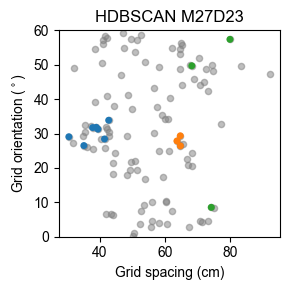

for module 0, there are 7 cells with average spacing 37.99662690122387
for module 1, there are 3 cells with average spacing 64.32183667886112
for module 2, there are 3 cells with average spacing 74.05830307100051
module 0 contains cells from ['ENTm2' 'ENTm3' 'VISpl5' 'VISpl6a']
module 1 contains cells from ['ENTm2' 'ENTm3']
module 2 contains cells from ['ENTm2' 'VISpl5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


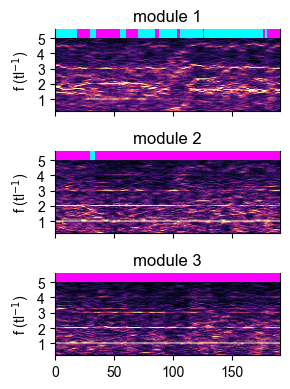

Identified 1 candidate modules
27 26
optimal travel lag is 10.660660660660668 cm based on kde of travel at max spatial information
optimal travel lag is 10.660660660660668 cm
there are 22 non_grid and non_spatial_cells
there are 12 grid_cells
there are 20 non grid spatial cells
there are 2 non spatial cells
there are 1 speed cells
there are 35 cells
for the non-grid spatial cells the unique locations are ['PAR' 'VISpl5' 'VISpl6a']
for the grid cells the unique locations are ['PAR' 'VISpl5' 'VISpl6a']
unique brain regions ['CUL4, 5' 'FL' 'PAR' 'PFL' 'SIM' 'VISpl5' 'VISpl6a' 'arb' 'root']
there are 0 MEC cells
there are 19 PARA cells
there are 0 PRE cells
there are 15 VIS cells
there are 76 CERE cells
there are 1 other cells
there are 0 SUB cells
there are 111 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 3.3380266777636933
Merging labels 0 and 2 with 

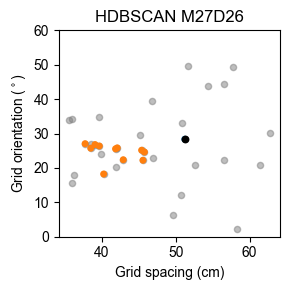

for module 0, there are 11 cells with average spacing 41.72919672948084
module 0 contains cells from ['PAR' 'VISpl5' 'VISpl6a']
Identified 1 candidate modules


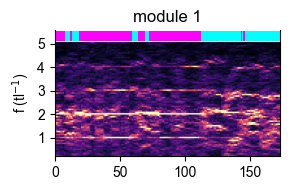

Identified 1 candidate modules
21 21
optimal travel lag is 6.656656656656658 cm based on kde of travel at max spatial information
optimal travel lag is 6.656656656656658 cm
there are 246 non_grid and non_spatial_cells
there are 39 grid_cells
there are 186 non grid spatial cells
there are 60 non spatial cells
there are 30 speed cells
there are 315 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6' 'HPF' 'VISl6a' 'VISp5' 'VISp6a'
 'VISpl6a' 'VISpl6b' 'ec']
for the grid cells the unique locations are ['ENTm1' 'ENTm3' 'ENTm5' 'ENTm6' 'HPF' 'VISl6a']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6' 'HPF' 'VISl6a' 'VISp5' 'VISp6a'
 'VISpl6a' 'VISpl6b' 'ec' 'root']
there are 202 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 86 VIS cells
there are 14 CERE cells
there are 38 other cells
there are 0 SUB cells
there are 340 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these 

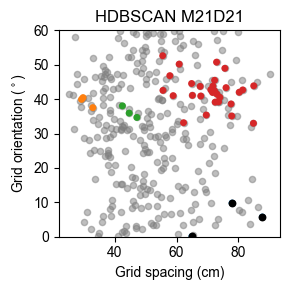

for module 0, there are 3 cells with average spacing 30.63998585780331
for module 1, there are 3 cells with average spacing 44.77260507515509
for module 2, there are 30 cells with average spacing 70.78125582859651
module 0 contains cells from ['ENTm6' 'HPF' 'VISl6a']
module 1 contains cells from ['ENTm5' 'HPF']
module 2 contains cells from ['ENTm1' 'ENTm3' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


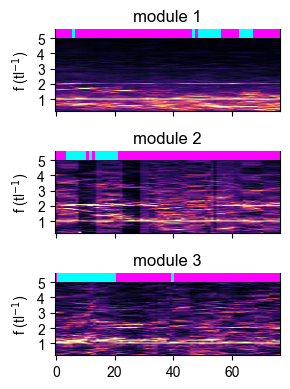

Identified 1 candidate modules
21 26
optimal travel lag is 6.556556556556558 cm based on kde of travel at max spatial information
optimal travel lag is 6.556556556556558 cm
there are 167 non_grid and non_spatial_cells
there are 23 grid_cells
there are 154 non grid spatial cells
there are 13 non spatial cells
there are 7 speed cells
there are 197 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6' 'HPF' 'VISl6a' 'VISp5' 'VISp6a'
 'VISpl6a' 'VISpl6b' 'ec']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5' 'ENTm6' 'VISp6a']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'ENTm6' 'HPF' 'VISl6a' 'VISp5' 'VISp6a'
 'VISpl6a' 'VISpl6b' 'ec']
there are 142 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 50 VIS cells
there are 0 CERE cells
there are 17 other cells
there are 0 SUB cells
there are 209 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to 

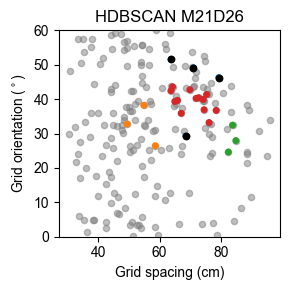

for module 0, there are 3 cells with average spacing 54.333783329440784
for module 1, there are 3 cells with average spacing 83.69406366201265
for module 2, there are 13 cells with average spacing 70.6942992937786
module 0 contains cells from ['ENTm5' 'ENTm6' 'VISp6a']
module 2 contains cells from ['ENTm2' 'ENTm3' 'ENTm5']
module 1 contains cells from ['ENTm2' 'ENTm5']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


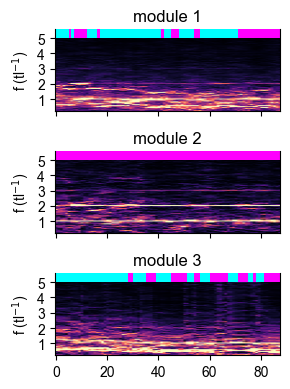

Identified 1 candidate modules
25 19
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 37 non_grid and non_spatial_cells
there are 12 grid_cells
there are 34 non grid spatial cells
there are 3 non spatial cells
there are 10 speed cells
there are 59 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'VISpl5']
for the grid cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'VISpl5']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'FL' 'VISpl5' 'root']
there are 46 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 13 VIS cells
there are 2 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 61 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 14.506768751034713
Found 3 modules with HDBSCAN fo

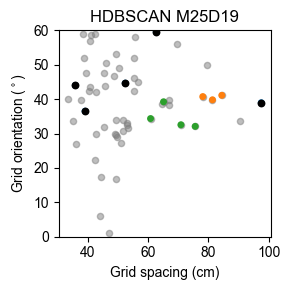

for module 0, there are 3 cells with average spacing 81.34142236534187
for module 1, there are 4 cells with average spacing 68.13287476384306
module 1 contains cells from ['ENTm1' 'ENTm2']
module 0 contains cells from ['ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules


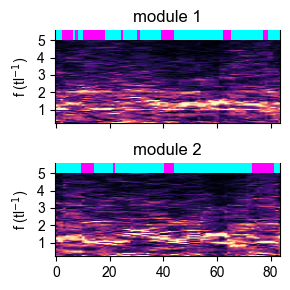

Identified 1 candidate modules
25 20
optimal travel lag is 9.05905905905906 cm based on kde of travel at max spatial information
optimal travel lag is 9.05905905905906 cm
there are 42 non_grid and non_spatial_cells
there are 13 grid_cells
there are 38 non grid spatial cells
there are 4 non spatial cells
there are 12 speed cells
there are 67 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
for the grid cells the unique locations are ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
unique brain regions ['ENTm1' 'ENTm2' 'FL' 'PAR' 'VISp5' 'VISpl5']
there are 42 MEC cells
there are 8 PARA cells
there are 0 PRE cells
there are 17 VIS cells
there are 1 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 68 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 15.741818751577284
Found 3 modules with HDBSCAN for mouse

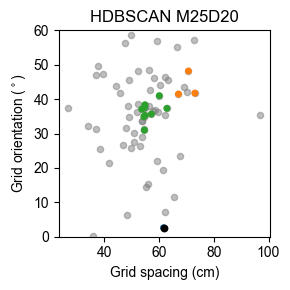

for module 0, there are 3 cells with average spacing 70.3536739667689
for module 1, there are 9 cells with average spacing 56.43120842495008
module 1 contains cells from ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
module 0 contains cells from ['ENTm1' 'ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules


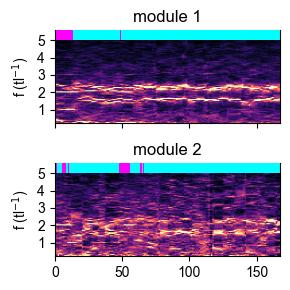

Identified 1 candidate modules
25 24
optimal travel lag is 6.856856856856858 cm based on kde of travel at max spatial information
optimal travel lag is 6.856856856856858 cm
there are 39 non_grid and non_spatial_cells
there are 24 grid_cells
there are 33 non grid spatial cells
there are 6 non spatial cells
there are 6 speed cells
there are 69 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
for the grid cells the unique locations are ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
unique brain regions ['ENTm1' 'ENTm2' 'PAR' 'VISp5' 'VISpl5']
there are 43 MEC cells
there are 8 PARA cells
there are 0 PRE cells
there are 18 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 69 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 26.056554362780552
Not merging labels 0 and 2 with distance 1

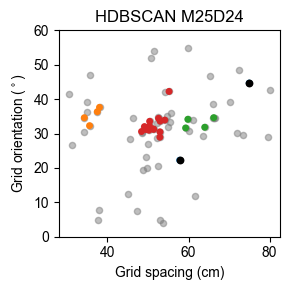

for module 0, there are 4 cells with average spacing 36.35747355941553
for module 1, there are 4 cells with average spacing 62.324193394413754
for module 2, there are 14 cells with average spacing 51.540367833089405
module 0 contains cells from ['VISpl5']
module 2 contains cells from ['ENTm2' 'VISpl5']
module 1 contains cells from ['ENTm1' 'ENTm2']
Identified 1 candidate modules
Identified 1 candidate modules
Identified 1 candidate modules


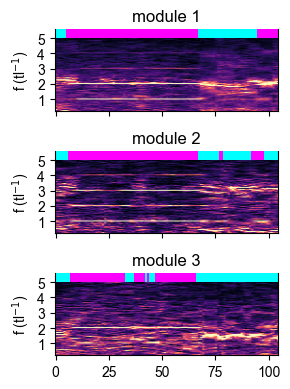

Identified 1 candidate modules
25 25
optimal travel lag is 0 cm
there are 105 non_grid and non_spatial_cells
there are 15 grid_cells
there are 89 non grid spatial cells
there are 16 non spatial cells
there are 32 speed cells
there are 152 cells
for the non-grid spatial cells the unique locations are ['PAR' 'VISp2/3' 'VISp4' 'VISpl2/3' 'VISpl4' 'VISpl5']
for the grid cells the unique locations are ['VISpl4' 'VISpl5']
unique brain regions ['PAR' 'VISl1' 'VISp2/3' 'VISp4' 'VISp5' 'VISpl2/3' 'VISpl4' 'VISpl5']
there are 0 MEC cells
there are 1 PARA cells
there are 0 PRE cells
there are 151 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 152 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 13.319892628463267
Found 2 modules with HDBSCAN for mouse 25 day 25
for each module , the number of points is: [ 5 10]


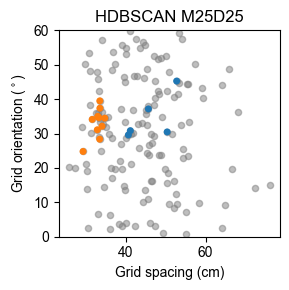

for module 0, there are 5 cells with average spacing 46.08683548764532
for module 1, there are 10 cells with average spacing 32.85419489549582
module 1 contains cells from ['VISpl4' 'VISpl5']
module 0 contains cells from ['VISpl5']
Identified 1 candidate modules
Identified 1 candidate modules


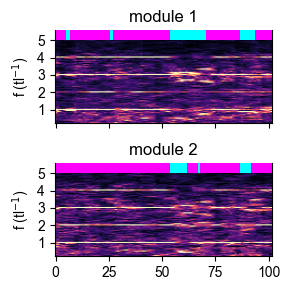

Identified 1 candidate modules
26 18
optimal travel lag is 12.362362362362369 cm based on kde of travel at max spatial information
optimal travel lag is 12.362362362362369 cm
there are 70 non_grid and non_spatial_cells
there are 11 grid_cells
there are 65 non grid spatial cells
there are 5 non spatial cells
there are 11 speed cells
there are 92 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'VISp2/3' 'VISp5' 'VISpl5']
for the grid cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'VISpl5']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'SIM' 'VISp2/3' 'VISp5' 'VISpl5' 'root']
there are 55 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 39 VIS cells
there are 9 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 103 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Merging labels 0 and 1 with distance 4.477396753522

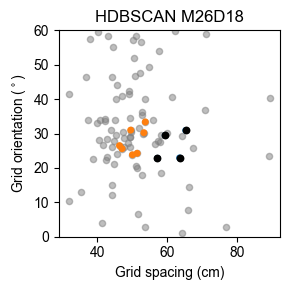

for module 0, there are 7 cells with average spacing 50.28227492928728
module 0 contains cells from ['ENTm1' 'ENTm2']
Identified 1 candidate modules


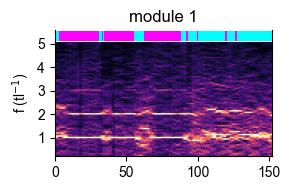

Identified 1 candidate modules
26 19
optimal travel lag is 9.55955955955956 cm based on kde of travel at max spatial information
optimal travel lag is 9.55955955955956 cm
there are 274 non_grid and non_spatial_cells
there are 32 grid_cells
there are 263 non grid spatial cells
there are 11 non spatial cells
there are 36 speed cells
there are 342 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpor5']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'PAR' 'VISpl5']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl5' 'VISpor5']
there are 265 MEC cells
there are 19 PARA cells
there are 0 PRE cells
there are 62 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 346 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 28.05718941

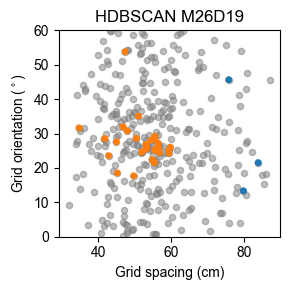

for module 0, there are 3 cells with average spacing 79.70418943974052
for module 1, there are 29 cells with average spacing 51.64994550698146
module 1 contains cells from ['ENTm2' 'ENTm3' 'PAR' 'VISpl5']
module 0 contains cells from ['ENTm2' 'ENTm3' 'VISpl5']
Identified 1 candidate modules
Identified 1 candidate modules


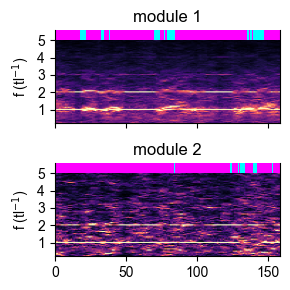

Identified 1 candidate modules


In [5]:
data = pd.DataFrame(columns=['mouse', 'day', 'cell_type', 'firing_mode', 'spatial_info'])

for mouse, days in mouse_days.items():
    for day in days:
        gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
        rc, rsc, vr_ns = cell_classification_vr(mouse, day)
        tcs, tcs_in_time, _ , last_ephys_bin, beh, clusters_VR = compute_vr_tcs(mouse, day, apply_zscore=False) 
        _, _, _, _, _, _, _, all_by_anatomy = cell_classification_anatomy(mouse,day)
        g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                        figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True) # create grid modules using HDBSCAN    

        # we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
        # as defined by activity in the open field
        g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
        cluster_ids_by_group = []
        cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
        cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
        cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
        cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
        cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

        # make spectrogram plot with task anchored and task independent labels
        fig, ax = plt.subplots(nrows=len(g_m_cluster_ids), 
                               ncols=1, figsize=(3, len(g_m_cluster_ids)+1), 
                               squeeze=False, sharex=True)
        peak_indices = [12, 28, 44, 60, 76]
        for m in range(len(g_m_cluster_ids)):
            cluster_ids = g_m_cluster_ids[m]
            tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
            results = spectral_analysis(tcs_to_use, tl, bs=bs)
            spectrograms = results[3] 
            fvalid = results[5]

            S = spectrograms.mean(0)
            ax[m,0].set_title(f'module {m+1}')
            ax[m,0].imshow(S,origin='lower',aspect='auto',vmax=0.25,cmap='magma')
            max_peaks = np.argmax(S, axis=0)
            ax[m,0].set_yticks(peak_indices, [1, 2, 3, 4, 5])
            ax[m,0].set_ylabel(r'f (tl$^{-1}$)')
            ax[m,0].spines['top'].set_visible(False)
            # Cluster labels: 1 if max at peak_indices_gm, else 0
            labels = np.isin(max_peaks, peak_indices).astype(int)
            ax[m,0].scatter(
                np.arange(S.shape[1]),
                np.full(S.shape[1], 81),  # y just above the top
                c=labels,
                cmap='cool',
                marker='s',
                s=50,
                vmin=0, 
                vmax=1,
                edgecolor='none',
                clip_on=True
            )
        plt.tight_layout()
        plt.show()

        # identify TA, TI labels
        cluster_ids = g_m_cluster_ids[0]
        tcs_to_use = {cluster_id: tcs[cluster_id] for cluster_id in cluster_ids if cluster_id in tcs}
        results = spectral_analysis(tcs_to_use, tl, bs=bs)
        spectrograms = results[3] 
        fvalid = results[5]
        S = spectrograms.mean(0)
        max_peaks = np.argmax(S, axis=0)
        labels = np.isin(max_peaks, peak_indices).astype(int) # 1 if max at peak_indices_gm, else 0

        # redefine cluster ids by group
        cmGC_cluster_ids = g_m_cluster_ids[0] # grid cells in the first module
        ncmGC_cluster_ids = np.setdiff1d(gcs.cluster_id.values.tolist(), cmGC_cluster_ids)
        ngs_cluster_ids = ngs.cluster_id.values.tolist() # non grid spatial cells

        # get mean probe location for the reference grid module
        x_pos_cmGC = []
        y_pos_cmGC = []
        for cluster_id in cmGC_cluster_ids:
            x_pos_cmGC.append(clusters_VR.coord_probe_x[cluster_id])
            y_pos_cmGC.append(clusters_VR.coord_probe_y[cluster_id])
        x_pos_cmGC = np.nanmean(np.array(x_pos_cmGC))
        y_pos_cmGC = np.nanmean(np.array(y_pos_cmGC))

        # now compute spatial information for each cell type
        for cluster_ids, cell_type in zip([cmGC_cluster_ids, ncmGC_cluster_ids, ngs_cluster_ids], ['cmGC', 'ncmGC', 'NGS']):
            if len(cluster_ids) == 0:
                continue
            for cluster_id in cluster_ids:
                tc = tcs[cluster_id]
                tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                tc = tc[:last_ephys_bin] # only want bins with ephys data in it
                tcz = zscore(tc)
                bin_config = get_bin_config('VR')
                trial_labels = get_kmeans_spatial_labels(tcz, labels, bs=bs, tl=tl) # reuse kmeans function to get the labels based on the task anchoring
                x_pos = clusters_VR.coord_probe_x[cluster_id]
                y_pos = clusters_VR.coord_probe_y[cluster_id]

                dist = np.sqrt((x_pos - x_pos_cmGC)**2 + (y_pos - y_pos_cmGC)**2) # distance from the mean position of the reference grid module
                
                for_plot = []
                for firing_mode, label in zip(['TA', 'TI'], [1, 0]):
                    trials = beh['trials'][:len(trial_labels)]
                    trials = trials[trial_labels == label]
                    #print(f'Computing spatial info for {mouse} {day} {cell_type} {firing_mode} {cluster_id}, with {len(trials)} trials')
                    x, y = get_avg_profile(tc, bs, tl, mask=trial_labels==label)

                    spatial_info = nap.compute_1d_mutual_info(y.reshape(-1, 1), 
                                                              beh['P'], 
                                                              ep=beh['moving'].intersect(trials), 
                                                              minmax=bin_config['P']['bounds'])['SI'].iloc[0]
                    df = pd.DataFrame({
                        'mouse': mouse,
                        'day': day,
                        'cluster_id': cluster_id,
                        'cell_type': cell_type,
                        'firing_mode': firing_mode,
                        'spatial_info': spatial_info,
                        'dist_from_module': dist,
                    }, index=[0])

                    data = pd.concat([data, df], ignore_index=True)
                    for_plot.append(spatial_info)
                
                # plot firing rate map with task anchorin
                fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(rm_figsize[0], rm_figsize[1]*1.45), sharex=True, height_ratios=[0.3, 1], width_ratios=[1,0.05], sharey='row')
                plot_firing_rate_map(ax[1,0], tc, bs=bs, tl=tl, p=95, sort_indices=None)
                ax[1,1].axis('off')
                ax[0,1].axis('off')
                ax[1,1].scatter(np.ones(len(trial_labels)), np.arange(0,len(trial_labels)),c=trial_labels,cmap='cool',marker='s',vmin=0, vmax=1)
                ax[1,0].set_xlabel('Pos (cm)')
                cmap = plt.get_cmap('cool')
                for group in np.unique(trial_labels):
                    if len(trial_labels[trial_labels == group])>5:
                        x, y = get_avg_profile(tc, bs, tl, mask=trial_labels==group)
                        ax[0,0].plot(x,y, color=cmap(group), linewidth=1)
                        ax[0,0].set_title(f'TA {for_plot[0]:.2f} | TI {for_plot[1]:.2f}')
                fig.savefig(f'/Users/harryclark/Documents/figs/TA_versus_TI_spatial_information/M{mouse}D{day}{label}{cluster_id}_with_avg_task_anchoring.pdf', dpi=300, bbox_inches='tight')
                plt.close()




In [6]:
data

,mouse,day,cell_type,firing_mode,spatial_info,cluster_id,dist_from_module
0,27,23,cmGC,TA,0.154530,239.0,192.911315
1,27,23,cmGC,TI,0.098509,239.0,192.911315
2,27,23,cmGC,TA,0.064724,263.0,102.958680
3,27,23,cmGC,TI,0.011074,263.0,102.958680
4,27,23,cmGC,TA,0.040250,269.0,58.037462
...,...,...,...,...,...,...,...
2333,26,19,NGS,TI,0.013805,524.0,586.598830
2334,26,19,NGS,TA,0.009596,525.0,575.461058
2335,26,19,NGS,TI,0.003059,525.0,575.461058
2336,26,19,NGS,TA,0.019414,526.0,575.461058


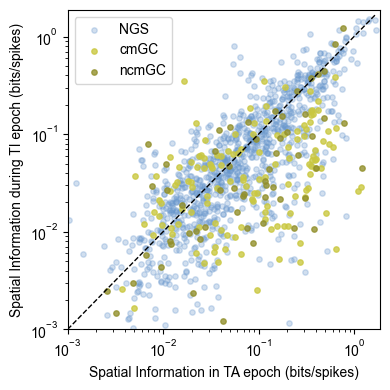

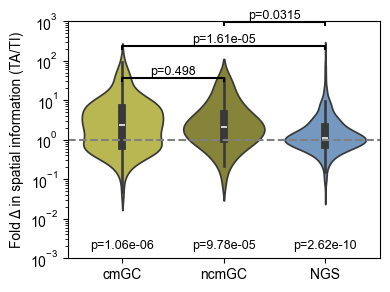

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp, ttest_ind
import numpy as np

cell_types = ['cmGC', 'ncmGC', 'NGS']
colors = {'cmGC': '#CAC841', 'ncmGC': "#92902C", 'NGS': '#6897CD'}

pivot = data.pivot_table(index=['mouse', 'day', 'cell_type', 'cluster_id'], columns='firing_mode', values='spatial_info').reset_index()

# --- Scatter plot (TA vs TI) ---
plt.figure(figsize=(4, 4))
subset_ngs = pivot[pivot['cell_type'] == 'NGS']
plt.scatter(subset_ngs['TA'], subset_ngs['TI'], color=colors['NGS'], label='NGS', alpha=0.3, s=15, zorder=1)
for ct in ['cmGC', 'ncmGC']:
    subset = pivot[pivot['cell_type'] == ct]
    plt.scatter(subset['TA'], subset['TI'], color=colors[ct], label=ct, alpha=0.8, s=15, zorder=2)
plt.plot([1e-3, pivot[['TA','TI']].max().max()], [1e-3, pivot[['TA','TI']].max().max()], 'k--', lw=1)
plt.xlabel('Spatial Information in TA epoch (bits/spikes)')
plt.ylabel('Spatial Information during TI epoch (bits/spikes)')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-3, pivot[['TA','TI']].max().max()*1.1)
plt.ylim(1e-3, pivot[['TA','TI']].max().max()*1.1)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/Fold_change_spatial_info_TA_vs_TI_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- Violin plot for fold change (TA/TI) ---
violin_data = []
violin_labels = []
group_folds = {}

for ct in cell_types:
    subset = pivot[pivot['cell_type'] == ct]
    fold_change = (subset['TA'] + 1e-6) / (subset['TI'] + 1e-6)
    group_folds[ct] = fold_change
    violin_data.extend(fold_change)
    violin_labels.extend([ct]*len(fold_change))

# One-tailed t-test (fold change > 1) for each group
pvals = []
for ct in cell_types:
    tstat, pval = ttest_1samp(group_folds[ct], 1, alternative='greater')
    pvals.append(pval)

plt.figure(figsize=(4, 3))
sns.violinplot(x=violin_labels, y=violin_data, palette=[colors[ct] for ct in cell_types], inner='box', log_scale=True)
for i, ct in enumerate(cell_types):
    vals = np.array(group_folds[ct])
    # Place p-value below each violin
    plt.text(i, (1e-2)-0.007, f'p={pvals[i]:.3g}', ha='center', color='black', fontsize=9, va='top')
plt.axhline(1, color='grey', linestyle='--')
plt.ylabel('Fold Δ in spatial information (TA/TI)')
plt.ylim(1e-3, 1e3)
plt.tight_layout()

# --- Between-group t-tests and annotation ---
# Place p-value annotations at fixed log-spaced heights above the violins
annotation_heights = [30, 200, 800]  # adjust as needed for clarity
annotation_idx = 0
for i, ct1 in enumerate(cell_types):
    for j, ct2 in enumerate(cell_types):
        if i < j:
            tstat, pval = ttest_ind(group_folds[ct1], group_folds[ct2], nan_policy='omit')
            x1, x2 = i, j
            y = annotation_heights[annotation_idx]
            plt.plot([x1, x1, x2, x2], [y, y*1.2, y*1.2, y], lw=1.5, c='k')
            plt.text((x1+x2)/2, y*1.22, f'p={pval:.3g}', ha='center', va='bottom', color='k', fontsize=9)
            annotation_idx += 1
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/Fold_change_spatial_info_TA_vs_TI_violin.pdf', dpi=300, bbox_inches='tight')
plt.show()

now I want to see if the distance to the grid module is related to the change in spatial information


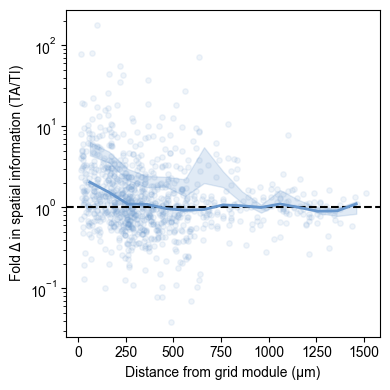

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cell_types = ['NGS']  # Plot NGS first, then ncmGC on top
colors = {'cmGC': '#CAC841', 'ncmGC': "#92902C", 'NGS': '#6897CD'}

pivot = data.pivot_table(
    index=['mouse', 'day', 'cell_type', 'cluster_id', 'dist_from_module'],
    columns='firing_mode',
    values='spatial_info'
).reset_index()
pivot['fold_change'] = (pivot['TA'] + 1e-6) / (pivot['TI'] + 1e-6)

# Bin distances
n_bins = 15
dist_min = pivot['dist_from_module'].min()
dist_max = pivot['dist_from_module'].max()
bins = np.linspace(dist_min, dist_max, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(figsize=(4, 4))

# Scatter plot
for ct in cell_types:
    subset = pivot[pivot['cell_type'] == ct]
    ax.scatter(subset['dist_from_module'], subset['fold_change'], color=colors[ct], label=ct, alpha=0.1, s=15, zorder=1)

# Binned average (all cell_types together, black line)
means = []
medians = []
sems = []
for i in range(n_bins):
    in_bin = (pivot['dist_from_module'] >= bins[i]) & (pivot['dist_from_module'] < bins[i+1])
    vals = pivot['fold_change'][in_bin]
    means.append(np.nanmean(vals) if len(vals) > 0 else np.nan)
    medians.append(np.nanmedian(vals) if len(vals) > 0 else np.nan)
    sems.append(np.nanstd(vals)/np.sqrt(np.sum(~np.isnan(vals))) if len(vals) > 1 else np.nan)
means = np.array(means)
medians = np.array(medians)
sems = np.array(sems)
ax.plot(bin_centers, medians, color='#6897CD', linewidth=2, zorder=3)
ax.fill_between(bin_centers, means-sems, means+sems, color='#6897CD', alpha=0.2, zorder=2)

ax.axhline(1, color='black', linestyle='--')
ax.set_xlabel('Distance from grid module (µm)')
ax.set_ylabel('Fold Δ in spatial information (TA/TI)')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/Fold_change_spatial_info_TA_vs_TI_binned.pdf', dpi=300, bbox_inches='tight')
plt.show()